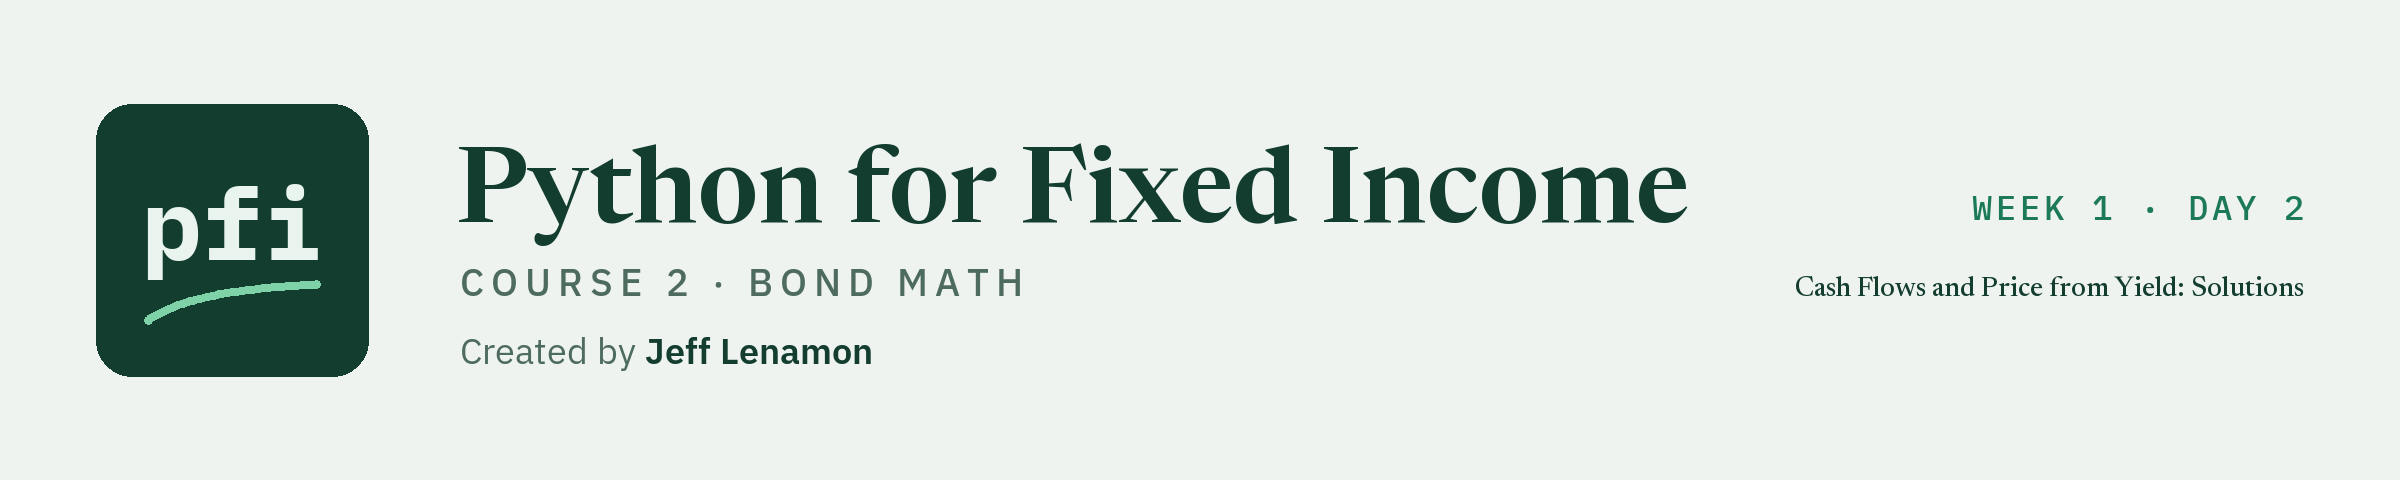

# Cash Flows and Price from Yield: Solutions

Week 1, Day 2. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day2/02_cash_flows_and_price_from_yield_solutions.ipynb)

This notebook stands on its own. Its setup writes `bondmath.py` and `test_bondmath.py` as they stand at the end of today, so the exercises can be run without the lesson.

Q. Set up today's work folder.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_02_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_02_nk5e02d6, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the end of today.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield']


## Exercises

The exercises use the second set of four bonds from day 1, bought on 30 September 2026 like the first four. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [5]:
exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
    "years": [4, 2, 6, 8],
    "yield_pct": [5.8, 4.3, 5.35, 8.6],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,yield_pct
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,4,5.80
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2,4.30
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,6,5.35
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,8,8.60


### Exercise 1

Q. With `bondmath.price_from_yield`, price each bond at its own yield, semiannual. Store Osmere's price in **ex1_osmere**, unrounded, and a list of the tickers of the bonds that price above 100 in **ex1_premium**.

In [6]:
# one price for each bond, at its own coupon, yield, and years
exercise_bonds["price"] = [
    bondmath.price_from_yield(c, y, t)
    for c, y, t in zip(exercise_bonds["coupon_pct"], exercise_bonds["yield_pct"], exercise_bonds["years"])
]
print(exercise_bonds[["ticker", "coupon_pct", "yield_pct", "years", "price"]].round(4))

ex1_osmere = exercise_bonds.loc[exercise_bonds["ticker"] == "OSMC", "price"].iloc[0]
# a boolean filter, then the ticker column as a list
ex1_premium = exercise_bonds.loc[exercise_bonds["price"] > 100, "ticker"].tolist()

print(f"Osmere: {ex1_osmere:.4f} per 100 of face. Above 100: {ex1_premium}")

  ticker  coupon_pct  yield_pct  years     price
0   OSTV       5.625       5.80      4   99.3832
1   TRNW       4.375       4.30      2  100.1423
2   OSMC       5.000       5.35      6   98.2238
3   CLDB       8.250       8.60      8   98.0052
Osmere: 98.2238 per 100 of face. Above 100: ['TRNW']


* Osmere prices at 98.2238. Excel's `=-PV(5.35/100/2,2*6,5/2,100)` returns 98.22376489690686.
* Only Tarnwick prices above 100, at 100.1423: its coupon, 4.375 percent, is the only one above its yield, 4.30 percent. The other three have coupons below their yields and price below 100.

In [7]:
check("Exercise 1 Osmere", ex1_osmere, 98.2237648969068)
check("Exercise 1 above 100", ex1_premium, ["TRNW"])

Exercise 1 Osmere: correct
Exercise 1 above 100: correct


### Exercise 2

Q. List Calderby's cash flows with `bondmath.cash_flows`. Store the number of payments in **ex2_payments**, the total cash it pays per 100 of face in **ex2_total_cash**, and the share of its price that comes from the redemption of 100, in percent and unrounded, in **ex2_redemption_share_pct**.

In [8]:
calderby = exercise_bonds[exercise_bonds["ticker"] == "CLDB"].iloc[0]
flows = bondmath.cash_flows(calderby["coupon_pct"], calderby["years"])

ex2_payments = len(flows)
# each item is a pair: add up the second value of every pair
ex2_total_cash = sum(amount for time_years, amount in flows)

# the redemption's present value over the whole price, in percent
price = bondmath.price_from_yield(calderby["coupon_pct"], calderby["yield_pct"], calderby["years"])
redemption_pv = bondmath.present_value(100, calderby["yield_pct"], calderby["years"])
ex2_redemption_share_pct = redemption_pv / price * 100

print(f"Payments: {ex2_payments}. Total cash: {ex2_total_cash:.2f} per 100 of face")
print(f"Redemption: {redemption_pv:.4f} of a price of {price:.4f}, {ex2_redemption_share_pct:.2f} percent")

Payments: 16. Total cash: 166.00 per 100 of face
Redemption: 50.9860 of a price of 98.0052, 52.02 percent


* 16 payments over 8 years, 166.00 per 100 of face in all: 16 coupons of 4.125 and the 100.
* The redemption is only 52.02 percent of Calderby's price. A long, high-coupon bond is worth mostly its coupons. For Quorvane, five years at 5.25 percent, the redemption was 77.1 percent.

In [9]:
check("Exercise 2 payments", ex2_payments, 16)
check("Exercise 2 total cash", ex2_total_cash, 166.0)
check("Exercise 2 redemption share", ex2_redemption_share_pct, 52.023761197236674)

Exercise 2 payments: correct
Exercise 2 total cash: correct
Exercise 2 redemption share: correct


### Exercise 3

Q. The desk holds 5,000,000 dollars of face of Ostrevale. Settlement is a coupon date, so there is no accrued interest. What is the position worth at its price, in dollars? Store it, unrounded, in **ex3_value_dollars**.

In [10]:
par_dollars = 5_000_000
price_per_100 = bondmath.price_from_yield(5.625, 5.80, 4)

# a price per 100 of face, scaled to the dollars of face held
ex3_value_dollars = par_dollars * price_per_100 / 100

print(f"Ostrevale at {price_per_100:.4f} per 100: {ex3_value_dollars:,.2f} dollars for {par_dollars:,} dollars of face")

Ostrevale at 99.3832 per 100: 4,969,158.88 dollars for 5,000,000 dollars of face


* 4,969,158.88 dollars. A price is per 100 of face, so the position's value is the face times the price over 100. On a coupon date this is also what the desk would be paid: no accrued interest is added.

In [11]:
check("Exercise 3 value in dollars", ex3_value_dollars, 4969158.881408045)

Exercise 3 value in dollars: correct


### Exercise 4

Q. Add a function to your module. `annual_coupon_income_dollars(par, coupon_pct)` returns the coupon income in dollars that `par` dollars of face earn in one year. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_annual_coupon_income_matches_cash_flows`, that checks a case by hand and checks the function, for 1,000,000 dollars of face, against one year of coupons from `bondmath.cash_flows` on every `PV_BOND` row of two years or more. Run pytest, and store `bondmath.annual_coupon_income_dollars(5_000_000, 5.625)` in **ex4_value**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [12]:
%%writefile -a bondmath.py


def annual_coupon_income_dollars(par: float, coupon_pct: float) -> float:
    """The coupon income a position earns in one year, in dollars.

    Units: par in dollars of face, coupon_pct in percent of face a year. Returns dollars.
    Convention: par x coupon_pct / 100, whatever the coupon frequency: the frequency splits the year's
    coupon into payments and does not change the total.
    Excel: =par*coupon_pct/100
    """
    # percent of face, applied to the dollars of face held
    return par * coupon_pct / 100

Appending to bondmath.py


In [13]:
%%writefile -a test_bondmath.py


def test_annual_coupon_income_matches_cash_flows():
    # a hand case: 1,000,000 dollars of face at 5.25 percent earns 52,500 dollars a year
    assert bondmath.annual_coupon_income_dollars(1_000_000, 5.25) == pytest.approx(52_500.0, abs=1e-6)
    # every Excel bond row of two years or more: one year of coupons from cash_flows, scaled to the position
    for row in tvm_rows("PV_BOND"):
        coupon_pct, years, frequency = float(row["coupon_pct"]), float(row["years"]), int(row["frequency"])
        if years < 2:
            continue
        first_year = bondmath.cash_flows(coupon_pct, years, frequency)[:frequency]
        per_100 = sum(amount for _, amount in first_year)
        expected = per_100 * 1_000_000 / 100
        assert bondmath.annual_coupon_income_dollars(1_000_000, coupon_pct) == pytest.approx(expected, abs=1e-6), row["case_id"]

Appending to test_bondmath.py


In [14]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......                                                                  [100%]
7 passed in 0.05s



In [15]:
# the file changed, so reload before calling the new function
importlib.reload(bondmath)

ex4_value = bondmath.annual_coupon_income_dollars(5_000_000, 5.625)
print(f"Ostrevale, 5,000,000 dollars of face at 5.625 percent: {ex4_value:,.2f} dollars a year")

Ostrevale, 5,000,000 dollars of face at 5.625 percent: 281,250.00 dollars a year


* `7 passed`: the six tests of the lesson and the new one.
* 281,250.00 dollars a year, paid as two coupons of 140,625.00. The frequency splits the year's coupon and does not change the total, so the function has no frequency argument.
* The test's first year is `cash_flows(...)[:frequency]`: one coupon for an annual bond, two for semiannual, four for quarterly. Rows of under two years are skipped because a bond with one year left returns its face in the first year too.
* Its Excel twin is `=5000000*5.625/100`.

In [16]:
check("Exercise 4 coupon income", ex4_value, 281250.0)

Exercise 4 coupon income: correct


### Exercise 5: AI check

You ask an AI assistant to write `price_from_yield` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Price of a bullet bond on a coupon date, from its yield.

Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, it returns a reasonable-looking number, and it contains one bug: a convention error.

* The bug: the code paid `coupon_pct`, the full annual coupon, every period. The docstring says coupons are paid `frequency` times a year, so each payment is `coupon_pct / frequency`. Quorvane paid 5.25 every half-year instead of 2.625, and priced at 122.0889 instead of 99.3503.
* The test caught it on the first `PV_BOND` row, `tvm_pv_bond_01`: 112.290325 against Excel's 98.634408. The zero-coupon row would have passed, because half of nothing is nothing, and so would any annual bond. That is why a test needs rows with coupons, at more than one frequency.
* The fix, in the cell below: `coupon = coupon_pct / frequency`.

In [17]:
def assistant_price_from_yield(coupon_pct, yield_pct, years, frequency=2):
    """Price of a bullet bond on a coupon date, from its yield.

Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the number of coupon periods, and the yield for one period as a decimal
    periods = round(years * frequency)
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for k in range(1, periods + 1):
        # the fix: each payment is the annual coupon split into `frequency` parts
        coupon = coupon_pct / frequency
        amount = coupon + 100 if k == periods else coupon
        price += amount / (1 + period_yield) ** k
    return price

In [18]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
bond_rows = tvm[tvm["function"] == "PV_BOND"]

for row in bond_rows.itertuples():
    result = assistant_price_from_yield(row.coupon_pct, row.rate_pct, row.years, row.frequency)
    # rate_pct is the yield; Excel's -PV with the coupon is the price per 100
    assert abs(result - row.excel_value) < 1e-6, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value:.6f}"

print(f"All {len(bond_rows)} PV_BOND rows match Excel")

All 20 PV_BOND rows match Excel


In [19]:
ex5_quorvane = assistant_price_from_yield(5.25, 5.40, 5)
ex5_rows = len(bond_rows)

print(f"Quorvane from the fixed function: {ex5_quorvane:.4f}")
print(f"PV_BOND rows checked: {ex5_rows}")

Quorvane from the fixed function: 99.3503
PV_BOND rows checked: 20


* 99.3503, the price from section 2.2, and all 20 rows match. The fixed function now does what its docstring says.

In [20]:
check("Exercise 5 Quorvane", ex5_quorvane, 99.35032727691542)
check("Exercise 5 rows checked", ex5_rows, 20)

Exercise 5 Quorvane: correct
Exercise 5 rows checked: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```